<a href="https://colab.research.google.com/github/taonanm/Insurance-Risk-Pricing-Model/blob/main/Insurance_Risk_Pricing_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Insurance Loss Severity & Risk-Based Pricing Model/train.csv")
df.head()

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


In [15]:
df.isnull().sum()

,0
id,0
cat1,0
cat2,0
cat3,0
cat4,0
...,...
cont11,0
cont12,0
cont13,0
cont14,0


In [16]:
df = pd.get_dummies(df, drop_first=True)
df["loss"].describe()

,loss
count,188318.000000
mean,3037.337686
std,2904.086186
min,0.670000
25%,1204.460000
50%,2115.570000
75%,3864.045000
max,121012.250000


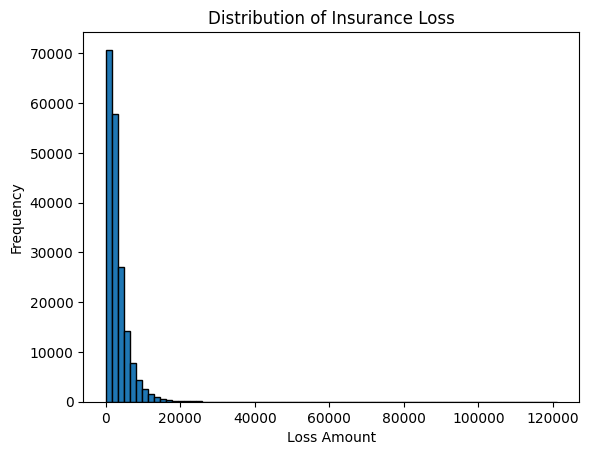

In [17]:
import matplotlib.pyplot as plt

plt.hist(df["loss"], bins=75, edgecolor="black")
plt.title("Distribution of Insurance Loss")
plt.xlabel("Loss Amount")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_6953/3717478953.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_loss"] = np.log(df["loss"])


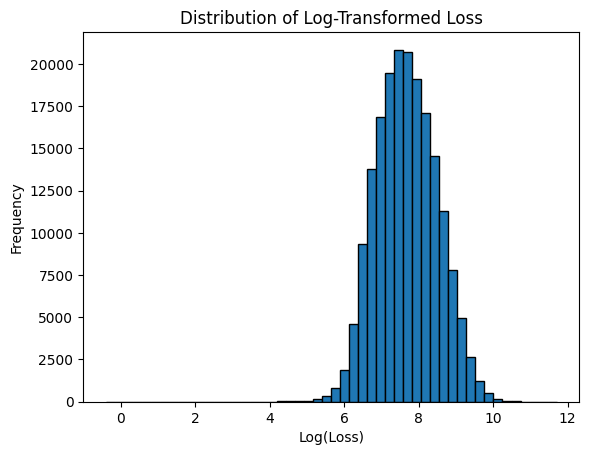

In [18]:
import matplotlib.pyplot as plt
import numpy as np

df["log_loss"] = np.log(df["loss"])
plt.hist(df["log_loss"], bins=50, edgecolor="black")

plt.title("Distribution of Log-Transformed Loss")
plt.xlabel("Log(Loss)")
plt.ylabel("Frequency")

plt.show()

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)
df.shape
df_encoded.shape

(188318, 1040)

In [20]:
X = df_encoded.drop(["loss", "log_loss", "id"], axis=1)
y = df_encoded["log_loss"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=20, n_jobs=-1, random_state=42)

In [23]:
rf_preds = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 0.34532150955366586
Random Forest R2: 0.4713108471668418


In [26]:
df = df.copy()

In [27]:
df["risk_level"] = pd.qcut(df["loss"], 3, labels=["Low", "Medium", "High"])

In [29]:
def pricing_model(loss):
    if loss < 2000:
        return loss * 1.1
    elif loss < 8000:
        return loss * 1.3
    else:
        return loss * 1.6

df["estimated_premium"] = df["loss"].apply(pricing_model)

df.groupby("risk_level", observed=False)["estimated_premium"].mean()

,estimated_premium
risk_level,
Low,1050.300183
Medium,2677.799152
High,8387.497042


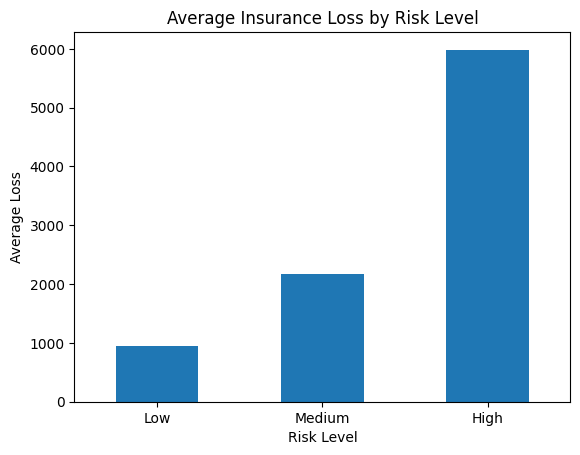

In [30]:
df.groupby("risk_level", observed=False)["loss"].mean().plot(kind="bar")

plt.title("Average Insurance Loss by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Loss")
plt.xticks(rotation=0)
plt.show()

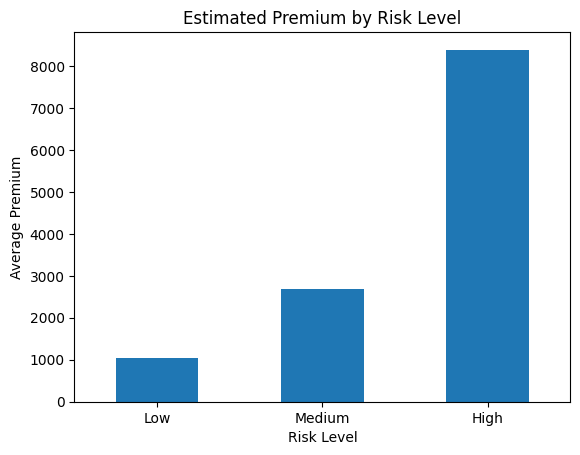

In [31]:
df.groupby("risk_level", observed=False)["estimated_premium"].mean().plot(kind="bar")

plt.title("Estimated Premium by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Premium")
plt.xticks(rotation=0)
plt.show()

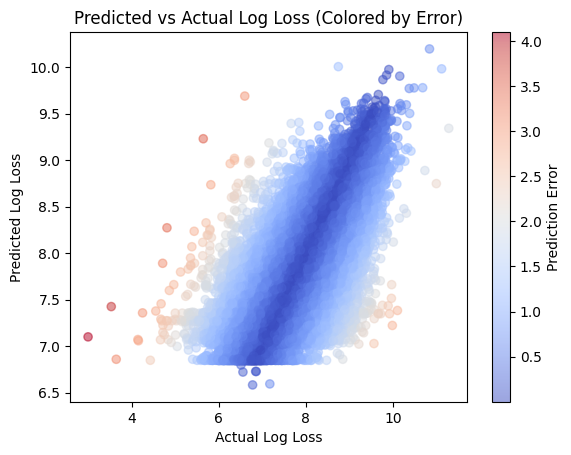

In [38]:
import numpy as np

errors = np.abs(y_test - rf_preds)

plt.scatter(y_test, rf_preds, c=errors, cmap="coolwarm", alpha=0.5)
plt.colorbar(label="Prediction Error")

plt.title("Predicted vs Actual Log Loss (Colored by Error)")
plt.xlabel("Actual Log Loss")
plt.ylabel("Predicted Log Loss")
plt.show()

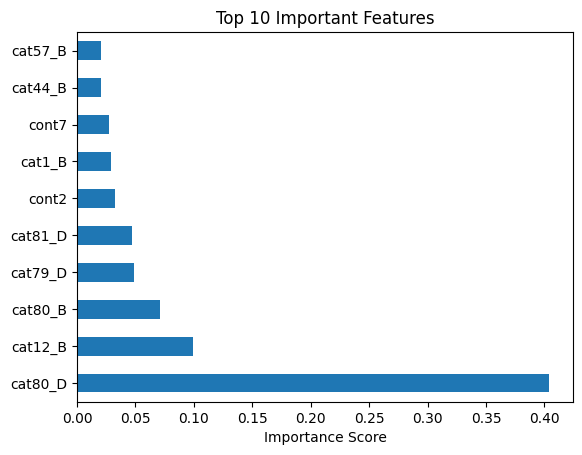

In [33]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()